In [1]:
import os
import re

# 1. Define the base directory
base_dir = "/scratch03.local/gtucci/micro/julia/"

# Tightened Regex: Forces the name to START with L_ followed by numbers, Dc, and kappa.
# This strictly ignores "test_...", "old_...", or formats missing 'kappa'.
pattern = re.compile(r"^L_[0-9.]+_Dc_([0-9.]+)_kappa_([0-9.]+)")

# 2. Populate the 'data' list of dictionaries dynamically
data = []

if os.path.exists(base_dir):
    for folder_name in sorted(os.listdir(base_dir)):
        match = pattern.match(
            folder_name
        )  # .match() checks from the start of the string
        if match:
            # Convert to float so they sort and display nicely as numbers
            dc_val = float(match.group(1))
            kappa_val = float(match.group(2))
            full_path = os.path.join(base_dir, folder_name)

            data.append({"Dc": dc_val, "kappa": kappa_val, "path": full_path})
else:
    print(f"Directory {base_dir} not found.")

# 3. Print the readable table (Deduplicated)
print("=== Summary Table (Strict Format & Unique) ===")
print(f"{'Dc':<10} | {'kappa':<10}")
print("-" * 23)

seen_combinations = set()

for entry in data:
    combo = (entry["Dc"], entry["kappa"])
    if combo not in seen_combinations:
        print(f"{entry['Dc']:<10.2f} | {entry['kappa']:<10.2f}")
        seen_combinations.add(combo)

print("\n" + "=" * 50 + "\n")

# 4. Print just the valid file paths for easy copying
print("=== Valid File Paths (Copy & Paste) ===")
for entry in data:
    print(entry["path"])

=== Summary Table (Strict Format & Unique) ===
Dc         | kappa     
-----------------------
1.00       | 0.10      
1.00       | 0.50      
1.00       | 1.00      
3.00       | 0.10      
3.00       | 0.50      
3.00       | 1.00      
6.00       | 0.10      
6.00       | 0.50      
6.00       | 1.00      


=== Valid File Paths (Copy & Paste) ===
/scratch03.local/gtucci/micro/julia/L_12.56_Dc_1.00_kappa_0.10_2026-06-03_162317
/scratch03.local/gtucci/micro/julia/L_12.56_Dc_1.00_kappa_0.50_2026-06-03_162317
/scratch03.local/gtucci/micro/julia/L_12.56_Dc_1.00_kappa_1.00_2026-06-03_162317
/scratch03.local/gtucci/micro/julia/L_12.56_Dc_3.00_kappa_0.10_2026-06-03_162317
/scratch03.local/gtucci/micro/julia/L_12.56_Dc_3.00_kappa_0.50_2026-06-03_162317
/scratch03.local/gtucci/micro/julia/L_12.56_Dc_3.00_kappa_1.00_2026-06-03_162317
/scratch03.local/gtucci/micro/julia/L_12.56_Dc_6.00_kappa_0.10_2026-06-03_162317
/scratch03.local/gtucci/micro/julia/L_12.56_Dc_6.00_kappa_0.50_2026-06-03_162317

There's a few approx equivalent ones in steady state:

width | days

10 | 

2 |

1 |

30 |

6 |

3 |

60 |

12 |

6 |

Wanna run a good subset like maybe
3, 6 (twice), 12 30, 60

(1.0 0.1), (10.0 1)

length of averaging window in time 63
peak width in number of sites(real space) = 1500.0000000000002


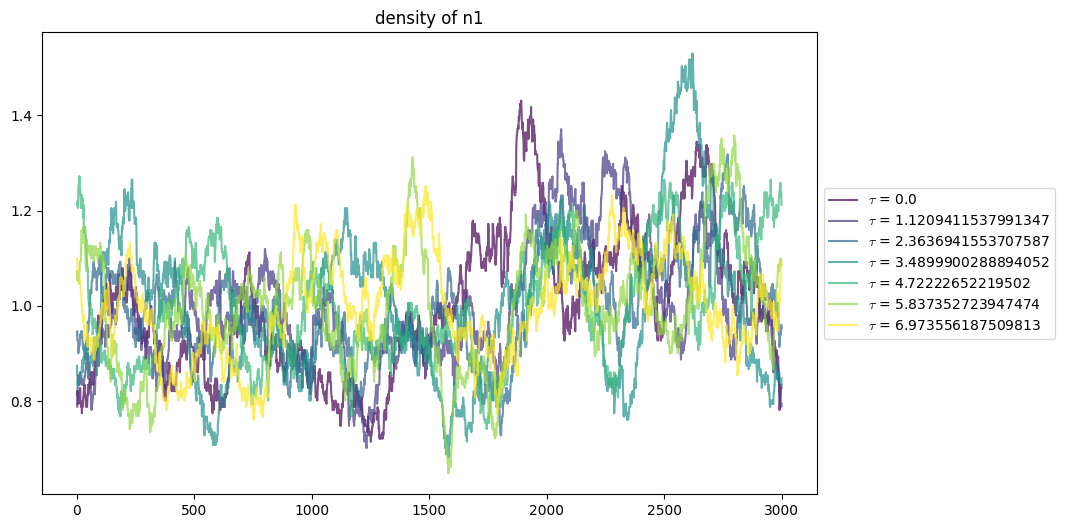

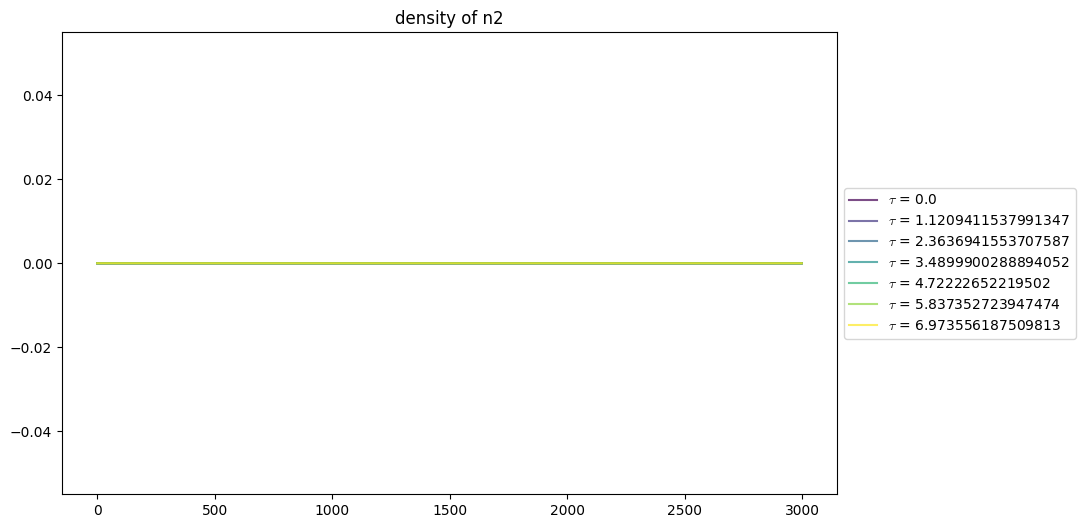

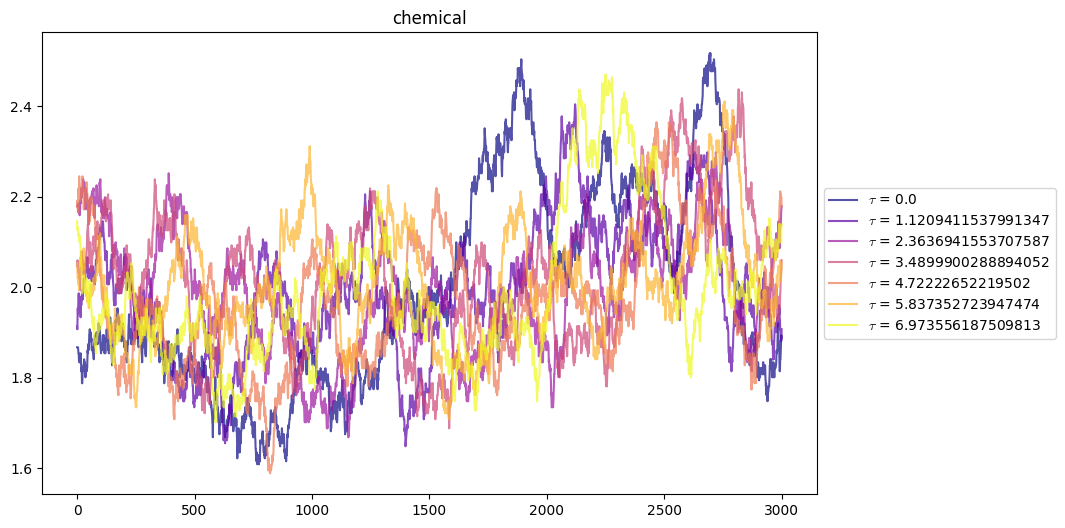

In [14]:
from helper_functions import *

path = '/scratch03.local/gtucci/micro/julia/L_12.56_Dc_6.00_kappa_1.00_2026-06-03_162317'

occupancies_t, tau_t, _, _, _ = load_sim(path)

s, e = 0.80, 1
rho = occupancies_t[int(s * occupancies_t.shape[0]):int(e * occupancies_t.shape[0]),0,:]
width = width_fourier(rho)
w = int(width) // 20

print("length of averaging window in time", rho.shape[0])
print("peak width in number of sites(real space) =", width)
plot_results(occupancies_t, tau_t, w, s, e, 7)

In [9]:
rho.shape

(5, 3000)